# Bonus: Comparison of Generative Models on MNIST

Compare images generated by RBM, DBN, VAE, GAN, and Diffusion Model, all with approximately the same number of parameters (~160k).

In [3]:
import os

REPO_URL = "https://github.com/sergio-contente/APM_5DS24_TP---Deep-Learning-II.git"
REPO_DIR = "/content/APM_5DS24_TP---Deep-Learning-II"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    !cd {REPO_DIR} && git pull

IMG_DIR = os.path.join(REPO_DIR, "images")
os.makedirs(IMG_DIR, exist_ok=True)
print(f"Repo cloned to {REPO_DIR}, images will be saved to {IMG_DIR}")

Already up to date.
Repo cloned to /content/APM_5DS24_TP---Deep-Learning-II, images will be saved to /content/APM_5DS24_TP---Deep-Learning-II/images


In [2]:
import sys
sys.path.insert(0, REPO_DIR)

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from src.utils import load_mnist

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

N_IMAGES = 10
MNIST_SHAPE = (28, 28)

Using device: cuda


## Load MNIST (binarized)

In [4]:
X_train_np, _, _, _ = load_mnist()
print(f"Train shape: {X_train_np.shape}")
print(f"Binarized: unique values = {np.unique(X_train_np)}")

X_train_tensor = torch.tensor(X_train_np, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(X_train_tensor), batch_size=128, shuffle=True)

Train shape: (60000, 784)
Binarized: unique values = [0. 1.]


## RBM & DBN (NumPy)

In [5]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def init_RBM(p, q):
    return {"W": np.random.randn(p, q) * 0.01, "a": np.zeros(p), "b": np.zeros(q)}

def entree_sortie_RBM(rbm, V):
    return sigmoid(V @ rbm["W"] + rbm["b"])

def sortie_entree_RBM(rbm, H):
    return sigmoid(H @ rbm["W"].T + rbm["a"])

def train_RBM(rbm, data, epochs=100, lr=0.1, batch_size=128):
    n = data.shape[0]
    for epoch in range(epochs):
        perm = np.random.permutation(n)
        epoch_error = 0.0
        n_batches = 0
        for start in range(0, n, batch_size):
            idx = perm[start:start+batch_size]
            v0 = data[idx]
            bs = v0.shape[0]
            h0_prob = entree_sortie_RBM(rbm, v0)
            h0_sample = (np.random.rand(*h0_prob.shape) < h0_prob).astype(np.float64)
            v1_prob = sortie_entree_RBM(rbm, h0_sample)
            h1_prob = entree_sortie_RBM(rbm, v1_prob)
            rbm["W"] += lr * (v0.T @ h0_prob - v1_prob.T @ h1_prob) / bs
            rbm["a"] += lr * np.mean(v0 - v1_prob, axis=0)
            rbm["b"] += lr * np.mean(h0_prob - h1_prob, axis=0)
            epoch_error += np.mean((v0 - v1_prob) ** 2)
            n_batches += 1
        if (epoch + 1) % 20 == 0:
            print(f"  RBM Epoch {epoch+1}/{epochs} - MSE: {epoch_error/n_batches:.6f}")

### 1. RBM (784 -> 200) ~158k params

In [6]:
print("Training RBM (784 -> 200)...")
print(f"Params: {784*200 + 784 + 200:,}")
rbm = init_RBM(784, 200)
train_RBM(rbm, X_train_np, epochs=100, lr=0.1, batch_size=128)

# Generate via Gibbs sampling
v = (np.random.rand(N_IMAGES, 784) > 0.5).astype(np.float64)
for _ in range(1000):
    h_prob = entree_sortie_RBM(rbm, v)
    h_sample = (np.random.rand(*h_prob.shape) < h_prob).astype(np.float64)
    v_prob = sortie_entree_RBM(rbm, h_sample)
    v = (np.random.rand(*v_prob.shape) < v_prob).astype(np.float64)
images_rbm = v
print("Done!")

Training RBM (784 -> 200)...
Params: 157,784
  RBM Epoch 20/100 - MSE: 0.017346
  RBM Epoch 40/100 - MSE: 0.015530
  RBM Epoch 60/100 - MSE: 0.014696
  RBM Epoch 80/100 - MSE: 0.014150
  RBM Epoch 100/100 - MSE: 0.013769
Done!


### 2. DBN (784 -> 200 -> 100) ~178k params

In [7]:
print("Training DBN (784 -> 200 -> 100)...")
print(f"Params: {784*200+784+200 + 200*100+200+100:,}")
dbn = [init_RBM(784, 200), init_RBM(200, 100)]

# Greedy layer-wise training
current_data = X_train_np.copy()
for i, r in enumerate(dbn):
    print(f"  Layer {i+1}: {r['W'].shape[0]} -> {r['W'].shape[1]}")
    train_RBM(r, current_data, epochs=100, lr=0.1, batch_size=128)
    current_data = entree_sortie_RBM(r, current_data)

# Generate: Gibbs at top RBM, then top-down
top_rbm = dbn[-1]
v_top = (np.random.rand(N_IMAGES, 200) > 0.5).astype(np.float64)
for _ in range(1000):
    h_p = entree_sortie_RBM(top_rbm, v_top)
    h_s = (np.random.rand(*h_p.shape) < h_p).astype(np.float64)
    v_p = sortie_entree_RBM(top_rbm, h_s)
    v_top = (np.random.rand(*v_p.shape) < v_p).astype(np.float64)
images_dbn = sortie_entree_RBM(dbn[0], v_top)
print("Done!")

Training DBN (784 -> 200 -> 100)...
Params: 178,084
  Layer 1: 784 -> 200
  RBM Epoch 20/100 - MSE: 0.017346
  RBM Epoch 40/100 - MSE: 0.015544
  RBM Epoch 60/100 - MSE: 0.014749
  RBM Epoch 80/100 - MSE: 0.014238
  RBM Epoch 100/100 - MSE: 0.013856
  Layer 2: 200 -> 100
  RBM Epoch 20/100 - MSE: 0.060419
  RBM Epoch 40/100 - MSE: 0.055241
  RBM Epoch 60/100 - MSE: 0.052722
  RBM Epoch 80/100 - MSE: 0.051233
  RBM Epoch 100/100 - MSE: 0.050058
Done!


## PyTorch Models

### 3. VAE ~160k params

In [8]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=100, latent_dim=10):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU())
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, input_dim), nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        return mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


vae = VAE().to(DEVICE)
print(f"VAE params: {sum(p.numel() for p in vae.parameters()):,}")
opt_vae = optim.Adam(vae.parameters(), lr=1e-3)

for epoch in range(300):
    total_loss = 0
    for (batch,) in train_loader:
        batch = batch.to(DEVICE)
        recon, mu, logvar = vae(batch)
        bce = nn.functional.binary_cross_entropy(recon, batch, reduction="sum")
        kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = (bce + kld) / batch.size(0)
        opt_vae.zero_grad()
        loss.backward()
        opt_vae.step()
        total_loss += loss.item()
    if (epoch + 1) % 10 == 0:
        print(f"  VAE Epoch {epoch+1}/300 - Loss: {total_loss/len(train_loader):.2f}")

with torch.no_grad():
    z = torch.randn(N_IMAGES, 10).to(DEVICE)
    images_vae = vae.decode(z).cpu().numpy()
print("Done!")

VAE params: 160,804
  VAE Epoch 10/300 - Loss: 108.17
  VAE Epoch 20/300 - Loss: 103.57
  VAE Epoch 30/300 - Loss: 101.79
  VAE Epoch 40/300 - Loss: 100.73
  VAE Epoch 50/300 - Loss: 99.94
  VAE Epoch 60/300 - Loss: 99.33
  VAE Epoch 70/300 - Loss: 98.93
  VAE Epoch 80/300 - Loss: 98.63
  VAE Epoch 90/300 - Loss: 98.30
  VAE Epoch 100/300 - Loss: 98.03
  VAE Epoch 110/300 - Loss: 97.85
  VAE Epoch 120/300 - Loss: 97.66
  VAE Epoch 130/300 - Loss: 97.45
  VAE Epoch 140/300 - Loss: 97.33
  VAE Epoch 150/300 - Loss: 97.21
  VAE Epoch 160/300 - Loss: 97.09
  VAE Epoch 170/300 - Loss: 96.98
  VAE Epoch 180/300 - Loss: 96.87
  VAE Epoch 190/300 - Loss: 96.79
  VAE Epoch 200/300 - Loss: 96.72
  VAE Epoch 210/300 - Loss: 96.62
  VAE Epoch 220/300 - Loss: 96.52
  VAE Epoch 230/300 - Loss: 96.46
  VAE Epoch 240/300 - Loss: 96.42
  VAE Epoch 250/300 - Loss: 96.37
  VAE Epoch 260/300 - Loss: 96.27
  VAE Epoch 270/300 - Loss: 96.20
  VAE Epoch 280/300 - Loss: 96.15
  VAE Epoch 290/300 - Loss: 96.07

### 4. GAN ~210k params

In [9]:
LATENT_DIM_GAN = 64

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM_GAN, 128), nn.ReLU(),
            nn.Linear(128, 784), nn.Sigmoid(),
        )
    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 1), nn.Sigmoid(),
        )
    def forward(self, x):
        return self.net(x)

gen = Generator().to(DEVICE)
disc = Discriminator().to(DEVICE)
print(f"GAN params - G: {sum(p.numel() for p in gen.parameters()):,}, D: {sum(p.numel() for p in disc.parameters()):,}, Total: {sum(p.numel() for p in gen.parameters()) + sum(p.numel() for p in disc.parameters()):,}")

opt_g = optim.Adam(gen.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_d = optim.Adam(disc.parameters(), lr=2e-4, betas=(0.5, 0.999))
bce_loss = nn.BCELoss()

for epoch in range(200):
    total_g, total_d = 0, 0
    for (real,) in train_loader:
        real = real.to(DEVICE)
        bs = real.size(0)
        ones = torch.ones(bs, 1, device=DEVICE)
        zeros = torch.zeros(bs, 1, device=DEVICE)

        z = torch.randn(bs, LATENT_DIM_GAN, device=DEVICE)
        fake = gen(z).detach()
        loss_d = bce_loss(disc(real), ones) + bce_loss(disc(fake), zeros)
        opt_d.zero_grad()
        loss_d.backward()
        opt_d.step()

        z = torch.randn(bs, LATENT_DIM_GAN, device=DEVICE)
        fake = gen(z)
        loss_g = bce_loss(disc(fake), ones)
        opt_g.zero_grad()
        loss_g.backward()
        opt_g.step()

        total_d += loss_d.item()
        total_g += loss_g.item()
    if (epoch + 1) % 20 == 0:
        print(f"  GAN Epoch {epoch+1}/200 - D: {total_d/len(train_loader):.3f}, G: {total_g/len(train_loader):.3f}")

with torch.no_grad():
    z = torch.randn(N_IMAGES, LATENT_DIM_GAN, device=DEVICE)
    images_gan = gen(z).cpu().numpy()
print("Done!")

GAN params - G: 109,456, D: 100,609, Total: 210,065
  GAN Epoch 20/200 - D: 0.657, G: 1.735
  GAN Epoch 40/200 - D: 0.687, G: 1.874
  GAN Epoch 60/200 - D: 0.764, G: 1.608
  GAN Epoch 80/200 - D: 1.254, G: 1.138
  GAN Epoch 100/200 - D: 0.696, G: 1.708
  GAN Epoch 120/200 - D: 0.727, G: 1.609
  GAN Epoch 140/200 - D: 0.727, G: 1.689
  GAN Epoch 160/200 - D: 0.610, G: 1.968
  GAN Epoch 180/200 - D: 0.566, G: 2.124
  GAN Epoch 200/200 - D: 0.564, G: 2.158
Done!


### 5. Diffusion Model (simple DDPM) ~168k params

In [10]:
T_STEPS = 500
betas = torch.linspace(1e-4, 0.02, T_STEPS)
alphas = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0).to(DEVICE)

class DenoisingNet(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=100, t_emb_dim=16):
        super().__init__()
        self.t_embed = nn.Sequential(nn.Linear(1, t_emb_dim), nn.ReLU())
        self.net = nn.Sequential(
            nn.Linear(input_dim + t_emb_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )
    def forward(self, x, t):
        t_emb = self.t_embed(t.float().unsqueeze(-1) / T_STEPS)
        return self.net(torch.cat([x, t_emb], dim=-1))

diffusion = DenoisingNet().to(DEVICE)
print(f"Diffusion params: {sum(p.numel() for p in diffusion.parameters()):,}")
opt_diff = optim.Adam(diffusion.parameters(), lr=1e-3)

for epoch in range(200):
    total_loss = 0
    for (batch,) in train_loader:
        batch = batch.to(DEVICE)
        bs = batch.size(0)
        t = torch.randint(0, T_STEPS, (bs,), device=DEVICE)
        noise = torch.randn_like(batch)
        ab = alpha_bar[t].unsqueeze(-1)
        x_noisy = torch.sqrt(ab) * batch + torch.sqrt(1 - ab) * noise
        pred_noise = diffusion(x_noisy, t)
        loss = nn.functional.mse_loss(pred_noise, noise)
        opt_diff.zero_grad()
        loss.backward()
        opt_diff.step()
        total_loss += loss.item()
    if (epoch + 1) % 10 == 0:
        print(f"  Diffusion Epoch {epoch+1}/200 - Loss: {total_loss/len(train_loader):.4f}")

# Reverse sampling
betas_d = betas.to(DEVICE)
alphas_d = alphas.to(DEVICE)
with torch.no_grad():
    x = torch.randn(N_IMAGES, 784, device=DEVICE)
    for t in reversed(range(T_STEPS)):
        t_batch = torch.full((N_IMAGES,), t, device=DEVICE)
        pred_noise = diffusion(x, t_batch)
        x = (1 / torch.sqrt(alphas_d[t])) * (x - (betas_d[t] / torch.sqrt(1 - alpha_bar[t])) * pred_noise)
        if t > 0:
            x += torch.sqrt(betas_d[t]) * torch.randn_like(x)
    images_diff = torch.clamp(x, 0, 1).cpu().numpy()
print("Done!")

Diffusion params: 169,416
  Diffusion Epoch 10/200 - Loss: 0.9100
  Diffusion Epoch 20/200 - Loss: 0.9080
  Diffusion Epoch 30/200 - Loss: 0.9078
  Diffusion Epoch 40/200 - Loss: 0.9081
  Diffusion Epoch 50/200 - Loss: 0.9075
  Diffusion Epoch 60/200 - Loss: 0.9075
  Diffusion Epoch 70/200 - Loss: 0.9071
  Diffusion Epoch 80/200 - Loss: 0.9066
  Diffusion Epoch 90/200 - Loss: 0.9066
  Diffusion Epoch 100/200 - Loss: 0.9061
  Diffusion Epoch 110/200 - Loss: 0.9064
  Diffusion Epoch 120/200 - Loss: 0.9059
  Diffusion Epoch 130/200 - Loss: 0.9059
  Diffusion Epoch 140/200 - Loss: 0.9063
  Diffusion Epoch 150/200 - Loss: 0.9057
  Diffusion Epoch 160/200 - Loss: 0.9060
  Diffusion Epoch 170/200 - Loss: 0.9057
  Diffusion Epoch 180/200 - Loss: 0.9059
  Diffusion Epoch 190/200 - Loss: 0.9058
  Diffusion Epoch 200/200 - Loss: 0.9055
Done!


## Comparison Figure

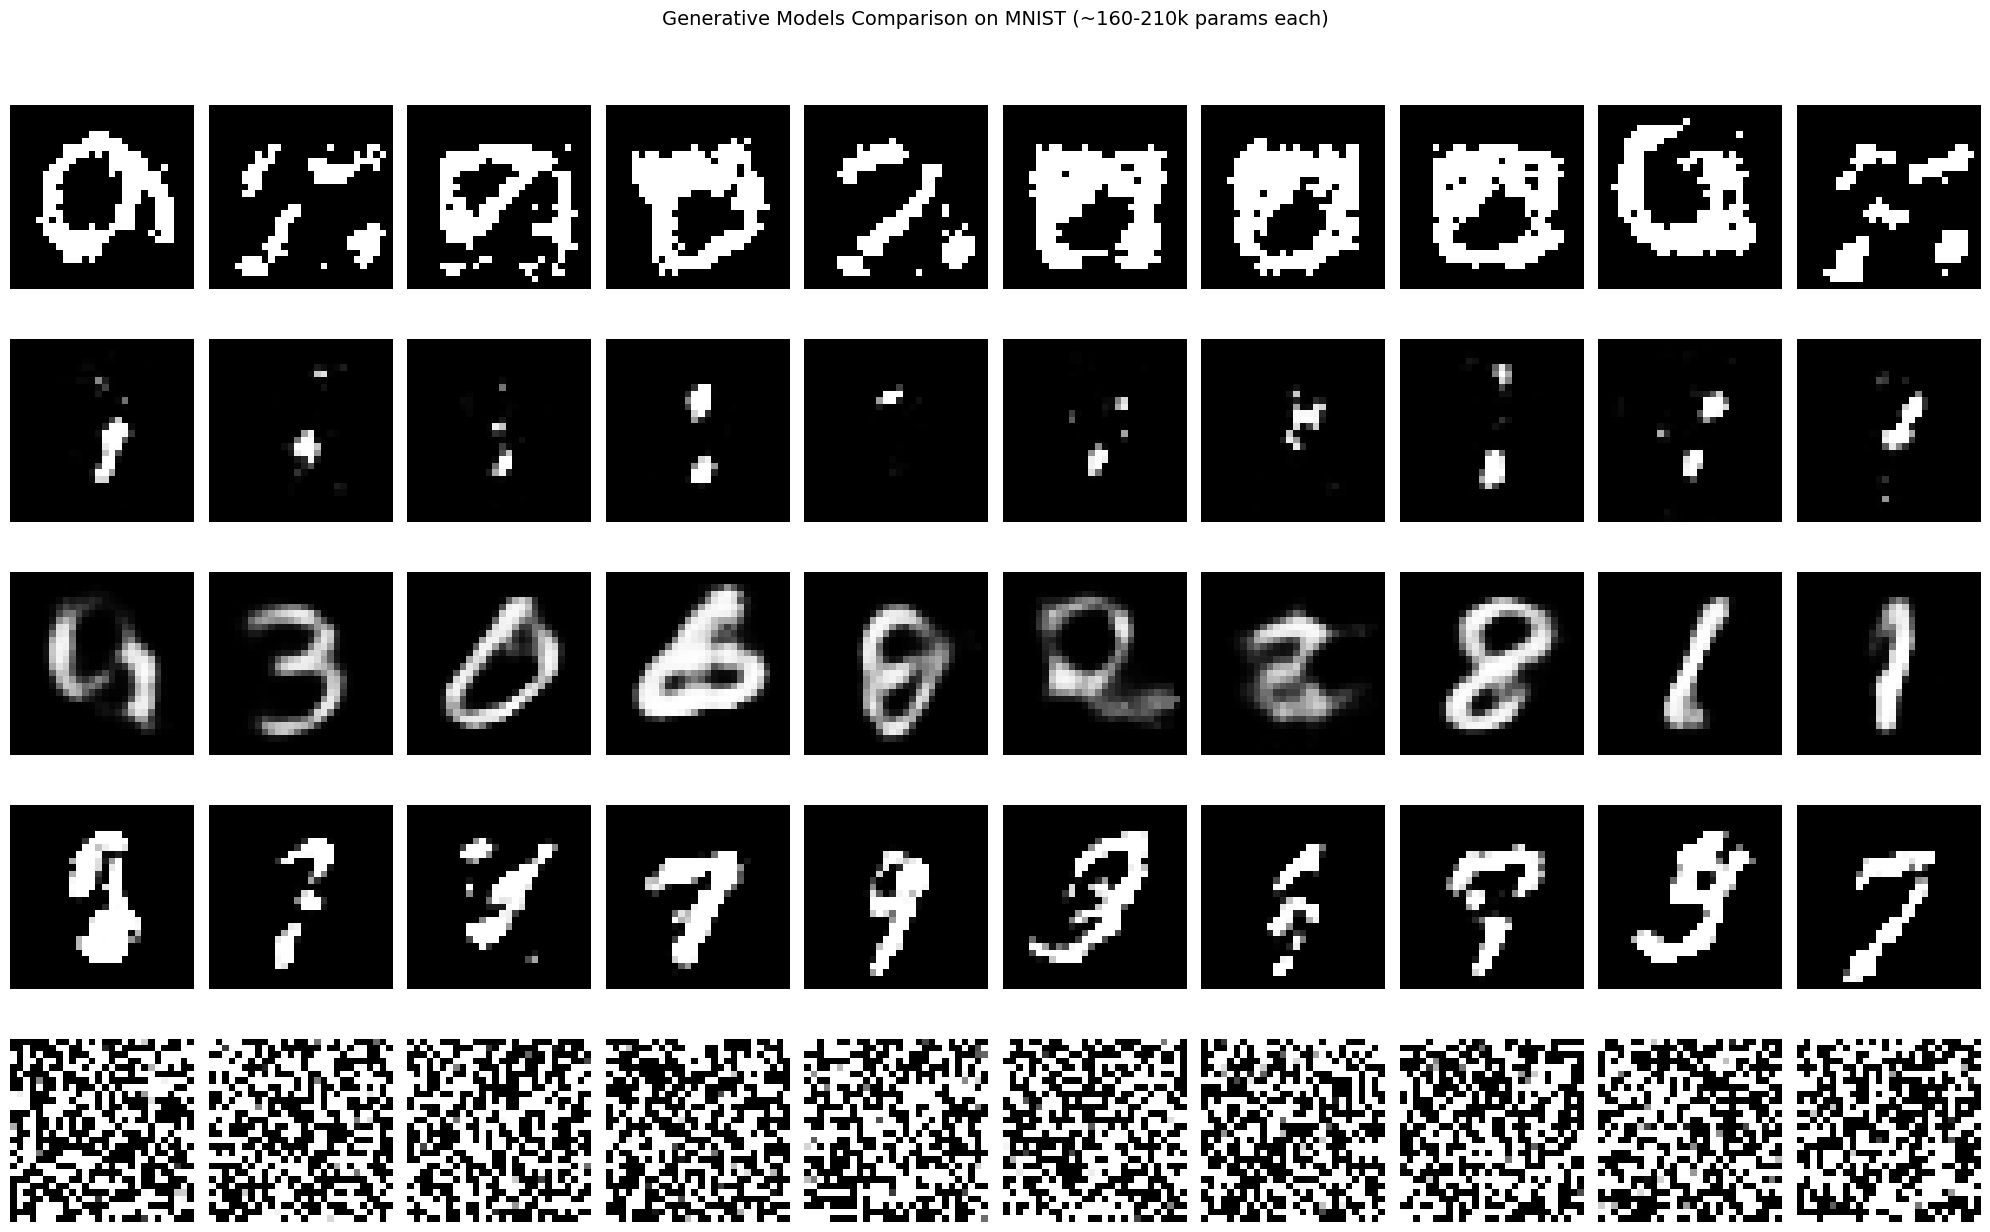


Saved to /content/APM_5DS24_TP---Deep-Learning-II/images/bonus_comparison.png

Parameter counts:
  RBM:       157,784
  DBN:       178,084
  VAE:       160,804
  GAN:       210,065
  Diffusion: 169,416


In [11]:
all_images = {
    "RBM\n(784->200)": images_rbm,
    "DBN\n(784->200->100)": images_dbn,
    "VAE\n(784->100->10)": images_vae,
    "GAN\n(64->128->784)": images_gan,
    "Diffusion\n(DDPM, T=500)": images_diff,
}

n_models = len(all_images)
fig, axes = plt.subplots(n_models, N_IMAGES, figsize=(2 * N_IMAGES, 2.5 * n_models))

for row, (name, imgs) in enumerate(all_images.items()):
    for col in range(N_IMAGES):
        ax = axes[row, col]
        ax.imshow(imgs[col].reshape(MNIST_SHAPE), cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(name, fontsize=11, rotation=0, labelpad=80, va="center")

plt.suptitle("Generative Models Comparison on MNIST (~160-210k params each)", fontsize=14, y=1.01)
plt.tight_layout()

save_path = os.path.join(IMG_DIR, "bonus_comparison.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"\nSaved to {save_path}")
print("\nParameter counts:")
print(f"  RBM:       {784*200 + 784 + 200:,}")
print(f"  DBN:       {784*200+784+200 + 200*100+200+100:,}")
print(f"  VAE:       {sum(p.numel() for p in vae.parameters()):,}")
print(f"  GAN:       {sum(p.numel() for p in gen.parameters()) + sum(p.numel() for p in disc.parameters()):,}")
print(f"  Diffusion: {sum(p.numel() for p in diffusion.parameters()):,}")